# Customer Churn Data Profiling

## Objective

This notebook performs an initial assessment of the telecommunications customer churn training dataset.

The profiling process evaluates:

- Dataset dimensions and structure
- Data types
- Missing values
- Duplicate records
- Target variable distribution
- Numerical feature distributions
- Categorical feature cardinality
- Potential data-quality issues
- Potential target leakage

The purpose of this notebook is to understand the raw data before applying cleaning, transformation, or feature engineering.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.s3 import load_csv_from_s3

In [3]:
df = load_csv_from_s3("raw/cell2celltrain.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 51,047
Columns: 58


In [4]:
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [5]:
df.tail()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.3,2.7,48.3,0.0,0.0,58.9,17.0,1.3,160.3,33.3,12.0,0.0,0.3,29,1,1,LAXSFN818,2.0,2.0,526.0,68.0,64.0,No,Yes,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,No,No,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,16.7,0.7,41.3,0.0,0.0,681.5,89.7,33.3,318.7,248.3,17.3,0.0,14.3,29,1,1,LAXCDG310,2.0,2.0,464.0,48.0,48.0,Yes,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,No,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.7,4.3,287.0,1.3,13.7,1225.3,430.3,87.7,1359.0,910.3,76.0,0.0,6.7,25,1,1,LAXCDG310,3.0,2.0,378.0,36.0,0.0,No,No,Yes,No,No,Known,No,No,No,No,No,Yes,0,0,No,No,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31,1,1,NEVPOW619,2.0,2.0,433.0,32.0,0.0,Yes,No,Yes,No,No,Unknown,No,No,No,No,No,No,0,0,No,No,0,9,No,0,30,No,5-Low,Other,Other,No
51046,3399994,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.7,0.7,117.3,1.3,1.0,330.9,55.0,16.7,442.3,167.3,19.3,0.0,0.0,25,1,1,NEVPOW619,7.0,5.0,75.0,0.0,0.0,No,No,Yes,No,No,Unknown,No,No,No,No,No,No,2,1,No,No,0,0,No,1,60,Yes,5-Low,Other,Other,Unknown


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  str    
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  float64
 14  T

In [7]:
df.dtypes.value_counts()

float64    26
str        23
int64       9
Name: count, dtype: int64

In [8]:
duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")

Duplicate rows: 0


In [9]:
print(f"Unique customer IDs: {df['CustomerID'].nunique():,}")
print(f"Total rows: {len(df):,}")
print(f"Duplicate customer IDs: {df['CustomerID'].duplicated().sum():,}")

Unique customer IDs: 51,047
Total rows: 51,047
Duplicate customer IDs: 0


In [10]:
missing = (
    df.isnull()
      .sum()
      .to_frame("missing_count")
)

missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
)

missing = (
    missing[missing["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

missing

,missing_count,missing_percent
AgeHH2,909,1.780712
AgeHH1,909,1.780712
PercChangeRevenues,367,0.718945
PercChangeMinutes,367,0.718945
MonthlyRevenue,156,0.305601
MonthlyMinutes,156,0.305601
RoamingCalls,156,0.305601
OverageMinutes,156,0.305601
DirectorAssistedCalls,156,0.305601
TotalRecurringCharge,156,0.305601


In [11]:
df["Churn"].value_counts()

Churn
No     36336
Yes    14711
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     71.18146
Yes    28.81854
Name: proportion, dtype: float64

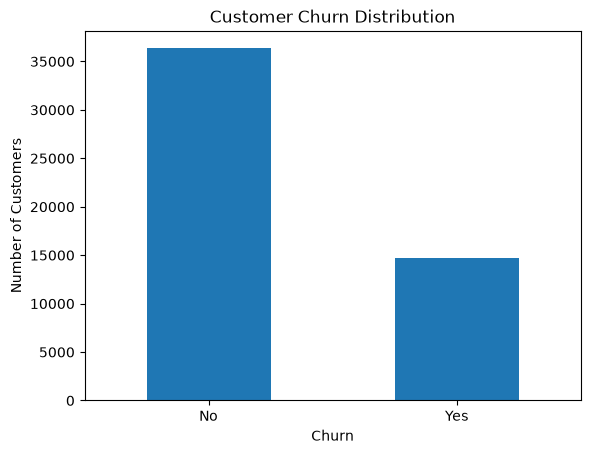

In [13]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,51047.0,3.201957e+06,116905.561666,3000002.00,3100632.00,3201534.00,3305376.000,3399994.00
MonthlyRevenue,50891.0,5.883449e+01,44.507336,-6.17,33.61,48.46,71.065,1223.38
MonthlyMinutes,50891.0,5.256534e+02,529.871063,0.00,158.00,366.00,723.000,7359.00
TotalRecurringCharge,50891.0,4.683009e+01,23.848871,-11.00,30.00,45.00,60.000,400.00
DirectorAssistedCalls,50891.0,8.952290e-01,2.228546,0.00,0.00,0.25,0.990,159.39
OverageMinutes,50891.0,4.002778e+01,96.588076,0.00,0.00,3.00,41.000,4321.00
RoamingCalls,50891.0,1.236244e+00,9.818294,0.00,0.00,0.00,0.300,1112.40
PercChangeMinutes,50680.0,-1.154791e+01,257.514772,-3875.00,-83.00,-5.00,66.000,5192.00
PercChangeRevenues,50680.0,-1.191985e+00,39.574915,-1107.70,-7.10,-0.30,1.600,2483.50
DroppedCalls,51047.0,6.011489e+00,9.043955,0.00,0.70,3.00,7.700,221.70


In [15]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print(f"Categorical columns: {len(categorical_columns)}")

categorical_columns

Categorical columns: 23


C:\Users\Yohanes E\AppData\Local\Temp\ipykernel_5940\1178678705.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns.tolist()


['Churn',
 'ServiceArea',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'HandsetPrice',
 'MadeCallToRetentionTeam',
 'CreditRating',
 'PrizmCode',
 'Occupation',
 'MaritalStatus']

In [16]:
categorical_summary = pd.DataFrame({
    "unique_values": df[categorical_columns].nunique(),
    "missing_values": df[categorical_columns].isnull().sum()
}).sort_values("unique_values")

categorical_summary

,unique_values,missing_values
Churn,2,0
ChildrenInHH,2,0
HandsetRefurbished,2,0
HandsetWebCapable,2,0
RVOwner,2,0
TruckOwner,2,0
Homeownership,2,0
BuysViaMailOrder,2,0
OwnsComputer,2,0
RespondsToMailOffers,2,0


## Data Quality Investigation

### Duplicate Records

Check whether the dataset contains duplicate rows or multiple records associated with the same customer ID.

In [17]:
print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Unique CustomerIDs: {df['CustomerID'].nunique():,}")
print(f"Duplicate CustomerIDs: {df['CustomerID'].duplicated().sum():,}")

Duplicate rows: 0
Unique CustomerIDs: 51,047
Duplicate CustomerIDs: 0


In [18]:
usage_columns = [
    "MonthlyRevenue",
    "MonthlyMinutes",
    "TotalRecurringCharge",
    "DirectorAssistedCalls",
    "OverageMinutes",
    "RoamingCalls"
]

any_missing = df[usage_columns].isna().any(axis=1).sum()
all_missing = df[usage_columns].isna().all(axis=1).sum()

print(f"Customers with any missing usage values: {any_missing:,}")
print(f"Customers with all usage values missing: {all_missing:,}")

Customers with any missing usage values: 156
Customers with all usage values missing: 156


In [19]:
change_columns = [
    "PercChangeMinutes",
    "PercChangeRevenues"
]

any_missing = df[change_columns].isna().any(axis=1).sum()
all_missing = df[change_columns].isna().all(axis=1).sum()

print(f"Customers with either change value missing: {any_missing:,}")
print(f"Customers with both change values missing: {all_missing:,}")

Customers with either change value missing: 367
Customers with both change values missing: 367


### Missing Household Age Values

Both household age variables contain the same number of missing values. Check whether they are missing for the same customer records.

In [20]:
age_columns = [
    "AgeHH1",
    "AgeHH2"
]

any_missing = df[age_columns].isna().any(axis=1).sum()
all_missing = df[age_columns].isna().all(axis=1).sum()

print(f"Customers with either household age missing: {any_missing:,}")
print(f"Customers with both household ages missing: {all_missing:,}")

Customers with either household age missing: 909
Customers with both household ages missing: 909


### Negative Numerical Values

Initial descriptive statistics identified negative values in revenue, recurring charges, and equipment age. Determine how frequently these negative values occur before deciding whether they represent valid business activity or data-quality issues.

In [21]:
columns_to_check = [
    "MonthlyRevenue",
    "TotalRecurringCharge",
    "CurrentEquipmentDays"
]

for column in columns_to_check:
    negative_count = (df[column] < 0).sum()

    print(
        f"{column}: {negative_count:,} negative values "
        f"({negative_count / len(df) * 100:.4f}%)"
    )

MonthlyRevenue: 3 negative values (0.0059%)
TotalRecurringCharge: 8 negative values (0.0157%)
CurrentEquipmentDays: 76 negative values (0.1489%)


### Negative Equipment Age

Negative values in `CurrentEquipmentDays` may represent a data-quality issue because equipment age would normally be expected to be non-negative. Examine the distribution of these negative values.

In [22]:
df.loc[
    df["CurrentEquipmentDays"] < 0,
    "CurrentEquipmentDays"
].value_counts().sort_index()

CurrentEquipmentDays
-5.0     3
-4.0     6
-3.0    26
-2.0    23
-1.0    18
Name: count, dtype: int64

### Negative Monthly Revenue

Only three customers have negative monthly revenue. Examine these records to determine whether the negative values may be associated with account credits or billing adjustments.

In [23]:
df.loc[
    df["MonthlyRevenue"] < 0,
    [
        "CustomerID",
        "MonthlyRevenue",
        "TotalRecurringCharge",
        "MonthlyMinutes",
        "AdjustmentsToCreditRating",
        "Churn"
    ]
]

,CustomerID,MonthlyRevenue,TotalRecurringCharge,MonthlyMinutes,AdjustmentsToCreditRating,Churn
26596,3210322,-2.52,0.0,211.0,0,No
33352,3265738,-5.86,-5.0,0.0,0,No
48038,3378298,-6.17,-6.0,0.0,0,No


### Negative Recurring Charges

Eight customers have negative total recurring charges. Examine these records and compare them with monthly revenue and usage information.

In [24]:
df.loc[
    df["TotalRecurringCharge"] < 0,
    [
        "CustomerID",
        "MonthlyRevenue",
        "TotalRecurringCharge",
        "MonthlyMinutes",
        "Churn"
    ]
].sort_values("TotalRecurringCharge")

,CustomerID,MonthlyRevenue,TotalRecurringCharge,MonthlyMinutes,Churn
42186,3335626,37.24,-11.0,0.0,Yes
30764,3244958,34.62,-9.0,0.0,No
48038,3378298,-6.17,-6.0,0.0,No
23904,3188158,94.77,-6.0,908.0,Yes
33352,3265738,-5.86,-5.0,0.0,No
18432,3144294,19.93,-2.0,279.0,No
3605,3028134,21.94,-2.0,329.0,No
35304,3281886,3.56,-1.0,157.0,No


### Subscription Count Outliers

The maximum values of `UniqueSubs` and `ActiveSubs` are substantially larger than their typical values. Examine the upper percentiles of these variables to determine whether the maxima are isolated observations or part of a broader distribution.

In [25]:
df[["UniqueSubs", "ActiveSubs"]].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999, 1.00]
)

,UniqueSubs,ActiveSubs
0.900,2.0,2.0
0.950,3.0,2.0
0.990,5.0,4.0
0.995,5.0,4.0
0.999,7.0,5.0
1.000,196.0,53.0


### Extreme Subscription Records

The maximum subscription counts are substantially larger than the 99.9th percentile. Examine customers with the highest numbers of unique subscriptions to determine whether these values represent isolated records or a broader pattern.

In [26]:
df.nlargest(
    15,
    "UniqueSubs"
)[
    [
        "CustomerID",
        "UniqueSubs",
        "ActiveSubs",
        "MonthlyRevenue",
        "MonthlyMinutes",
        "MonthsInService",
        "Churn"
    ]
]

,CustomerID,UniqueSubs,ActiveSubs,MonthlyRevenue,MonthlyMinutes,MonthsInService,Churn
23267,3183090,196,53,67.74,0.0,14,Yes
19802,3155050,18,8,43.80,38.0,18,Yes
16602,3130126,13,3,146.62,1283.0,19,Yes
38835,3309810,13,5,10.00,462.0,11,Yes
5489,3042870,12,2,35.39,63.0,34,No
43004,3341670,12,3,32.74,105.0,6,No
48358,3380514,12,3,44.28,1393.0,9,No
7001,3054866,11,5,89.46,1731.0,31,Yes
29504,3234242,11,11,80.14,490.0,11,No
41602,3331326,11,5,16.52,102.0,13,Yes


### Frequency of Extreme Subscription Counts

The largest `UniqueSubs` value is highly isolated from the rest of the distribution. Count how many customers have unusually large subscription counts.

In [27]:
for threshold in [5, 10, 20, 50]:
    count = (df["UniqueSubs"] > threshold).sum()

    print(f"UniqueSubs > {threshold}: {count:,} customers")

UniqueSubs > 5: 234 customers
UniqueSubs > 10: 10 customers
UniqueSubs > 20: 1 customers
UniqueSubs > 50: 1 customers


### Zero-Valued Household Ages

The household age variables contain a large number of zero values. Examine how frequently zero occurs to determine whether it may represent a special or missing-value encoding rather than a literal age.

In [28]:
for column in ["AgeHH1", "AgeHH2"]:
    zero_count = (df[column] == 0).sum()
    non_missing_count = df[column].notna().sum()

    print(
        f"{column}: {zero_count:,} zeros "
        f"({zero_count / non_missing_count * 100:.2f}% of non-missing values)"
    )

AgeHH1: 13,917 zeros (27.76% of non-missing values)
AgeHH2: 26,087 zeros (52.03% of non-missing values)


### Household Age Distribution

Zero is highly prevalent in both household age variables, particularly `AgeHH2`. Examine the most frequently occurring values to better understand how these variables are encoded.

In [29]:
print("Most common AgeHH1 values:")
print(df["AgeHH1"].value_counts(dropna=False).head(15))

print("\nMost common AgeHH2 values:")
print(df["AgeHH2"].value_counts(dropna=False).head(15))

Most common AgeHH1 values:
AgeHH1
0.0     13917
46.0     2149
42.0     2074
50.0     2063
48.0     2055
44.0     2037
40.0     1979
52.0     1968
38.0     1967
36.0     1889
30.0     1875
32.0     1826
34.0     1823
54.0     1719
28.0     1657
Name: count, dtype: int64

Most common AgeHH2 values:
AgeHH2
0.0     26087
46.0     1487
48.0     1419
44.0     1411
50.0     1335
42.0     1330
52.0     1295
40.0     1292
38.0     1218
36.0     1193
34.0     1131
32.0     1120
30.0     1081
54.0     1075
NaN       909
Name: count, dtype: int64


### Percentage Change Variables

The percentage-change variables contain large positive and negative values. Examine their percentiles to determine whether these extreme values are isolated observations or part of the broader distributions.

In [30]:
df[
    ["PercChangeMinutes", "PercChangeRevenues"]
].quantile(
    [0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999]
)

,PercChangeMinutes,PercChangeRevenues
0.001,-1743.210,-222.6741
0.010,-848.000,-104.5210
0.050,-380.000,-47.6000
0.500,-5.000,-0.3000
0.950,345.000,46.5000
0.990,739.210,115.0630
0.999,1504.247,291.9889


### Categorical Feature Cardinality

Examine the number of unique values in each categorical variable to identify binary features, low-cardinality categories, and high-cardinality features that may require special treatment during modeling.

In [32]:
categorical_columns = df.select_dtypes(include="str").columns

categorical_cardinality = (
    df[categorical_columns]
    .nunique()
    .sort_values()
)

categorical_cardinality

Churn                        2
ChildrenInHH                 2
HandsetRefurbished           2
HandsetWebCapable            2
RVOwner                      2
TruckOwner                   2
Homeownership                2
BuysViaMailOrder             2
OwnsComputer                 2
RespondsToMailOffers         2
OptOutMailings               2
NonUSTravel                  2
NewCellphoneUser             2
HasCreditCard                2
NotNewCellphoneUser          2
OwnsMotorcycle               2
MadeCallToRetentionTeam      2
MaritalStatus                3
PrizmCode                    4
CreditRating                 7
Occupation                   8
HandsetPrice                16
ServiceArea                747
dtype: int64

### Binary Categorical Values

Most categorical variables contain two unique values. Examine their actual category labels to identify how binary information is represented in the raw dataset.

In [33]:
binary_columns = [
    column
    for column in categorical_columns
    if df[column].nunique() == 2
]

for column in binary_columns:
    print(f"{column}: {df[column].unique()}")

Churn: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
ChildrenInHH: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
HandsetRefurbished: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
HandsetWebCapable: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
TruckOwner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
RVOwner: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Homeownership: <StringArray>
['Known', 'Unknown']
Length: 2, dtype: str
BuysViaMailOrder: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
RespondsToMailOffers: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
OptOutMailings: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
NonUSTravel: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OwnsComputer: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
HasCreditCard: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
NewCellphoneUser: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
NotNewCellphoneUser: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OwnsMotorc

### Low-Cardinality Categorical Values

Examine the category labels of low-cardinality categorical variables before deciding how they should be encoded for analysis and modeling.

In [34]:
low_cardinality_columns = [
    "MaritalStatus",
    "PrizmCode",
    "CreditRating",
    "Occupation",
    "HandsetPrice"
]

for column in low_cardinality_columns:
    print(f"\n{column}:")
    print(df[column].value_counts(dropna=False))


MaritalStatus:
MaritalStatus
Unknown    19700
Yes        18651
No         12696
Name: count, dtype: int64

PrizmCode:
PrizmCode
Other       24655
Suburban    16378
Town         7589
Rural        2425
Name: count, dtype: int64

CreditRating:
CreditRating
2-High       18993
1-Highest     8522
3-Good        8410
5-Low         6499
4-Medium      5357
7-Lowest      2114
6-VeryLow     1152
Name: count, dtype: int64

Occupation:
Occupation
Other           37637
Professional     8755
Crafts           1519
Clerical          986
Self              879
Retired           733
Student           381
Homemaker         157
Name: count, dtype: int64

HandsetPrice:
HandsetPrice
Unknown    28982
30          7328
150         4115
130         2105
80          1960
10          1928
60          1776
200         1266
100         1235
40           249
400           46
250           20
300           13
180           10
500            8
240            6
Name: count, dtype: int64


### Handset Price Encoding

`HandsetPrice` is stored as a categorical string variable because it contains an `Unknown` category. Examine whether all other values can be interpreted as numeric prices.

In [35]:
handset_price_numeric = pd.to_numeric(
    df["HandsetPrice"],
    errors="coerce"
)

print(f"Original non-missing values: {df['HandsetPrice'].notna().sum():,}")
print(f"Converted numeric values: {handset_price_numeric.notna().sum():,}")
print(f"Values that became NaN: {handset_price_numeric.isna().sum():,}")

Original non-missing values: 51,047
Converted numeric values: 22,065
Values that became NaN: 28,982


### Service Area Cardinality

`ServiceArea` contains hundreds of unique categories. Examine the most frequent service areas and determine whether the distribution is highly concentrated or broadly spread across many locations.

In [36]:
df["ServiceArea"].value_counts(dropna=False).head(20)

ServiceArea
NYCBRO917    1684
HOUHOU281    1510
DALDAL214    1498
NYCMAN917    1182
APCFCH703     783
DALFTW817     782
SANSAN210     724
APCSIL301     670
SANAUS512     612
SFROAK510     605
SFRSFR415     565
NYCQUE917     533
ATLANE678     524
PHXPHX602     512
SFRSCL408     508
ATLATL678     507
STLSTL314     497
OHICOL614     486
MINMIN612     481
NEVLVS702     479
Name: count, dtype: int64

### Service Area Concentration

Examine how much of the dataset is represented by the most common service areas and how many service areas occur only rarely.

In [37]:
service_area_counts = df["ServiceArea"].value_counts()

top_20_share = service_area_counts.head(20).sum() / len(df) * 100
rare_areas = (service_area_counts < 10).sum()

print(f"Share of customers in top 20 service areas: {top_20_share:.2f}%")
print(f"Service areas with fewer than 10 customers: {rare_areas:,}")

Share of customers in top 20 service areas: 29.66%
Service areas with fewer than 10 customers: 324


### Cellphone User Status Consistency

`NewCellphoneUser` and `NotNewCellphoneUser` appear potentially complementary based on their names. Examine their joint values to determine whether they are logically consistent.

In [38]:
pd.crosstab(
    df["NewCellphoneUser"],
    df["NotNewCellphoneUser"]
)

NotNewCellphoneUser,No,Yes
NewCellphoneUser,,
No,34188,7035
Yes,9824,0


### Cellphone User Status and Tenure

Compare customer tenure across the combinations of `NewCellphoneUser` and `NotNewCellphoneUser` to better understand what these flags may represent.

In [39]:
df.groupby(
    ["NewCellphoneUser", "NotNewCellphoneUser"]
)["MonthsInService"].agg(
    ["count", "mean", "median"]
)

count       mean  median
NewCellphoneUser NotNewCellphoneUser                          
No               No                   34188  17.101234    15.0
                 Yes                   7035  23.426581    22.0
Yes              No                    9824  21.171417    19.0

### Retention Variable Consistency

Examine whether `MadeCallToRetentionTeam` is consistent with the recorded number of `RetentionCalls`.

In [40]:
pd.crosstab(
    df["MadeCallToRetentionTeam"],
    df["RetentionCalls"] > 0,
    rownames=["MadeCallToRetentionTeam"],
    colnames=["RetentionCalls > 0"]
)

RetentionCalls > 0,False,True
MadeCallToRetentionTeam,,
No,49302,0
Yes,0,1745


### Retention Offer Consistency

Check whether customers with accepted retention offers also have recorded retention calls.

In [41]:
pd.crosstab(
    df["RetentionOffersAccepted"] > 0,
    df["RetentionCalls"] > 0,
    rownames=["RetentionOffersAccepted > 0"],
    colnames=["RetentionCalls > 0"]
)

RetentionCalls > 0,False,True
RetentionOffersAccepted > 0,,
False,49302,864
True,0,881


### Retention Offer Count Validation

Check whether any customer has accepted more retention offers than the number of recorded retention calls.

In [42]:
invalid_retention_records = (
    df["RetentionOffersAccepted"] > df["RetentionCalls"]
).sum()

print(
    f"Customers with more accepted offers than retention calls: "
    f"{invalid_retention_records:,}"
)

Customers with more accepted offers than retention calls: 0


### Subscription Count Consistency

Check whether the number of active subscriptions ever exceeds the number of unique subscriptions recorded for a customer.

In [43]:
invalid_subscription_records = (
    df["ActiveSubs"] > df["UniqueSubs"]
).sum()

print(
    f"Customers with ActiveSubs greater than UniqueSubs: "
    f"{invalid_subscription_records:,}"
)

Customers with ActiveSubs greater than UniqueSubs: 0


### Handset Count Consistency

Check whether the number of handset models ever exceeds the total number of handsets recorded for a customer.

In [44]:
invalid_handset_records = (
    df["HandsetModels"] > df["Handsets"]
).sum()

print(
    f"Customers with HandsetModels greater than Handsets: "
    f"{invalid_handset_records:,}"
)

Customers with HandsetModels greater than Handsets: 0


### Non-Negative Activity Validation

Check whether activity and call-count variables contain any negative values that may indicate data-quality issues.

In [45]:
activity_columns = [
    "MonthlyMinutes",
    "OverageMinutes",
    "RoamingCalls",
    "DroppedCalls",
    "BlockedCalls",
    "UnansweredCalls",
    "CustomerCareCalls",
    "ThreewayCalls",
    "ReceivedCalls",
    "OutboundCalls",
    "InboundCalls",
    "PeakCallsInOut",
    "OffPeakCallsInOut",
    "DroppedBlockedCalls",
    "CallForwardingCalls",
    "CallWaitingCalls"
]

negative_activity = {
    column: int((df[column] < 0).sum())
    for column in activity_columns
}

negative_activity

{'MonthlyMinutes': 0,
 'OverageMinutes': 0,
 'RoamingCalls': 0,
 'DroppedCalls': 0,
 'BlockedCalls': 0,
 'UnansweredCalls': 0,
 'CustomerCareCalls': 0,
 'ThreewayCalls': 0,
 'ReceivedCalls': 0,
 'OutboundCalls': 0,
 'InboundCalls': 0,
 'PeakCallsInOut': 0,
 'OffPeakCallsInOut': 0,
 'DroppedBlockedCalls': 0,
 'CallForwardingCalls': 0,
 'CallWaitingCalls': 0}

### Account and Count Validation

Check account, subscription, handset, retention, referral, and tenure variables for unexpected negative values.

In [46]:
count_columns = [
    "MonthsInService",
    "UniqueSubs",
    "ActiveSubs",
    "Handsets",
    "HandsetModels",
    "RetentionCalls",
    "RetentionOffersAccepted",
    "ReferralsMadeBySubscriber",
    "AdjustmentsToCreditRating"
]

negative_counts = {
    column: int((df[column] < 0).sum())
    for column in count_columns
}

negative_counts

{'MonthsInService': 0,
 'UniqueSubs': 0,
 'ActiveSubs': 0,
 'Handsets': 0,
 'HandsetModels': 0,
 'RetentionCalls': 0,
 'RetentionOffersAccepted': 0,
 'ReferralsMadeBySubscriber': 0,
 'AdjustmentsToCreditRating': 0}

### Target Variable Validation

Confirm that the churn target contains only the expected categories.

In [47]:
expected_churn_values = {"Yes", "No"}
actual_churn_values = set(df["Churn"].dropna().unique())

print(f"Actual Churn values: {actual_churn_values}")
print(
    "Valid target values:",
    actual_churn_values == expected_churn_values
)

Actual Churn values: {'Yes', 'No'}
Valid target values: True


### Schema Validation

Confirm that the training dataset contains all expected columns before downstream processing.

In [48]:
expected_columns = {
    "CustomerID",
    "Churn",
    "MonthlyRevenue",
    "MonthlyMinutes",
    "TotalRecurringCharge",
    "DirectorAssistedCalls",
    "OverageMinutes",
    "RoamingCalls",
    "PercChangeMinutes",
    "PercChangeRevenues",
    "DroppedCalls",
    "BlockedCalls",
    "UnansweredCalls",
    "CustomerCareCalls",
    "ThreewayCalls",
    "ReceivedCalls",
    "OutboundCalls",
    "InboundCalls",
    "PeakCallsInOut",
    "OffPeakCallsInOut",
    "DroppedBlockedCalls",
    "CallForwardingCalls",
    "CallWaitingCalls",
    "MonthsInService",
    "UniqueSubs",
    "ActiveSubs",
    "ServiceArea",
    "Handsets",
    "HandsetModels",
    "CurrentEquipmentDays",
    "AgeHH1",
    "AgeHH2",
    "ChildrenInHH",
    "HandsetRefurbished",
    "HandsetWebCapable",
    "TruckOwner",
    "RVOwner",
    "Homeownership",
    "BuysViaMailOrder",
    "RespondsToMailOffers",
    "OptOutMailings",
    "NonUSTravel",
    "OwnsComputer",
    "HasCreditCard",
    "RetentionCalls",
    "RetentionOffersAccepted",
    "NewCellphoneUser",
    "NotNewCellphoneUser",
    "ReferralsMadeBySubscriber",
    "IncomeGroup",
    "OwnsMotorcycle",
    "AdjustmentsToCreditRating",
    "HandsetPrice",
    "MadeCallToRetentionTeam",
    "CreditRating",
    "PrizmCode",
    "Occupation",
    "MaritalStatus"
}

actual_columns = set(df.columns)

missing_columns = expected_columns - actual_columns
unexpected_columns = actual_columns - expected_columns

print(f"Missing expected columns: {missing_columns}")
print(f"Unexpected columns: {unexpected_columns}")
print(f"Schema valid: {not missing_columns and not unexpected_columns}")

Missing expected columns: set()
Unexpected columns: set()
Schema valid: True


## Reusable Validation Module

Run the production-style validation functions from `src/data/validate.py` against the raw training dataset.

In [49]:
from src.data.validate import run_all_validations

validation_results = run_all_validations(df)

validation_results

{'schema': {'missing_columns': set(),
  'unexpected_columns': set(),
  'schema_valid': True},
 'duplicates': {'duplicate_rows': 0, 'duplicate_customer_ids': 0},
 'target': {'actual_churn_values': {'No', 'Yes'}, 'target_valid': True},
 'subscriptions': {'active_subs_exceed_unique_subs': 0,
  'subscription_counts_valid': True},
 'handsets': {'handset_models_exceed_handsets': 0,
  'handset_counts_valid': True},
 'retention': {'retention_flag_mismatches': 0,
  'accepted_offers_exceed_calls': 0,
  'retention_data_valid': True},
 'non_negative_columns': {'negative_value_counts': {'MonthlyMinutes': 0,
   'OverageMinutes': 0,
   'RoamingCalls': 0,
   'DroppedCalls': 0,
   'BlockedCalls': 0,
   'UnansweredCalls': 0,
   'CustomerCareCalls': 0,
   'ThreewayCalls': 0,
   'ReceivedCalls': 0,
   'OutboundCalls': 0,
   'InboundCalls': 0,
   'PeakCallsInOut': 0,
   'OffPeakCallsInOut': 0,
   'DroppedBlockedCalls': 0,
   'CallForwardingCalls': 0,
   'CallWaitingCalls': 0,
   'MonthsInService': 0,
   'U

In [52]:
import importlib
import src.data.validate

importlib.reload(src.data.validate)

<module 'src.data.validate' from 'c:\\Users\\Yohanes E\\Desktop\\customer-churn-project\\src\\data\\validate.py'>

In [53]:
from src.data.validate import (
    run_all_validations,
    validation_passed,
)

In [54]:
validation_results = run_all_validations(df)

print(
    f"Overall validation passed: "
    f"{validation_passed(validation_results)}"
)

Overall validation passed: True


## Data Quality Summary

The raw training dataset passed all required structural validation checks.

### Validation Results

- No duplicate rows were identified.
- All 51,047 customer IDs are unique.
- The dataset contains the expected 58-column schema.
- The churn target contains only the expected `Yes` and `No` values.
- Active subscription counts do not exceed unique subscription counts.
- Handset model counts do not exceed total handset counts.
- Retention-related variables are internally consistent.
- Activity and count-based variables contain no unexpected negative values.

### Data Quality Issues Requiring Future Treatment

Several characteristics require additional preprocessing or modeling decisions:

- Missing values occur in structured groups across billing, usage, change, and household-age variables.
- `CurrentEquipmentDays` contains 76 negative observations ranging from -5 to -1.
- A small number of customers have negative revenue or recurring charges.
- `UniqueSubs` contains one extreme observation of 196 subscriptions.
- `AgeHH1` and `AgeHH2` contain substantial numbers of zero values that may represent special encodings.
- `HandsetPrice` contains numeric prices stored as strings alongside an `Unknown` category.
- `ServiceArea` is a high-cardinality feature with 747 categories and a long tail of rare locations.
- Percentage-change variables contain large positive and negative values that require careful interpretation.

These issues will be addressed during preprocessing and feature engineering rather than modifying the raw data directly.